In [1]:
import pandas as pd

In [2]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [3]:
df = pd.read_excel("assignment2_dataset.xlsx") 

In [4]:
df

,maths_score,reading_score,writing_score,placement_score,club_join_date,gender,city
0,66.0,NaN,61.0,86.0,2021.0,m,pune
1,63.0,93.0,64.0,60.0,2024.0,f,pune
2,98.0,92.0,68.0,75.0,2020.0,f,nagpur
3,60.0,94.0,73.0,86.0,NaN,m,mumbai
4,77.0,80.0,55.0,NaN,2024.0,f,pune
5,71.0,60.0,79.0,92.0,2023.0,m,nashik
6,67.0,79.0,69.0,86.0,2022.0,f,kolhapur
7,66.0,93.0,NaN,90.0,2018.0,f,mumbai
8,61.0,84.0,67.0,75.0,2021.0,m,pune
9,NaN,78.0,67.0,88.0,2021.0,m,nashik


In [5]:
df.head()

,maths_score,reading_score,writing_score,placement_score,club_join_date,gender,city
0,66.0,NaN,61.0,86.0,2021.0,m,pune
1,63.0,93.0,64.0,60.0,2024.0,f,pune
2,98.0,92.0,68.0,75.0,2020.0,f,nagpur
3,60.0,94.0,73.0,86.0,NaN,m,mumbai
4,77.0,80.0,55.0,NaN,2024.0,f,pune


In [6]:
df.isnull().sum()

maths_score        1
reading_score      1
writing_score      1
placement_score    1
club_join_date     1
gender             0
city               0
dtype: int64

In [7]:
numeric_cols = ['maths_score','reading_score','writing_score','placement_score']

In [8]:
for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_4046/1203606999.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [9]:
outlier_mask = pd.DataFrame(False, index=df.index, columns=numeric_cols)

In [10]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask[col] = (df[col] < lower) | (df[col] > upper)

In [11]:
outlier_mask

,maths_score,reading_score,writing_score,placement_score
0,False,False,False,False
1,False,False,False,True
2,True,False,False,False
3,False,False,False,False
4,False,False,True,False
5,False,False,True,False
6,False,False,False,False
7,False,False,False,False
8,False,False,False,False
9,False,False,False,False


In [12]:
import matplotlib.pyplot as plt

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


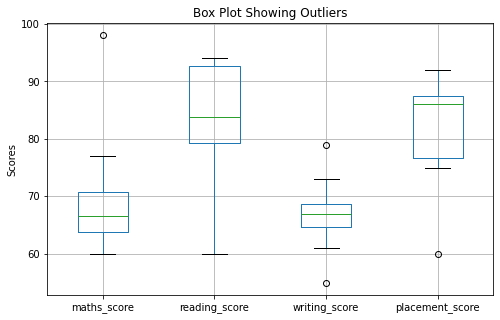

In [13]:
plt.figure(figsize=(8,5))
df[numeric_cols].boxplot()
plt.title("Box Plot Showing Outliers")
plt.ylabel("Scores")
plt.show()

In [14]:
# Trimming 
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [15]:
df

,maths_score,reading_score,writing_score,placement_score,club_join_date,gender,city
0,66.000000,83.666667,61.0,86.0,2021.0,m,pune
3,60.000000,94.000000,73.0,86.0,NaN,m,mumbai
6,67.000000,79.000000,69.0,86.0,2022.0,f,kolhapur
7,66.000000,93.000000,67.0,90.0,2018.0,f,mumbai
8,61.000000,84.000000,67.0,75.0,2021.0,m,pune
9,69.888889,78.000000,67.0,88.0,2021.0,m,nashik


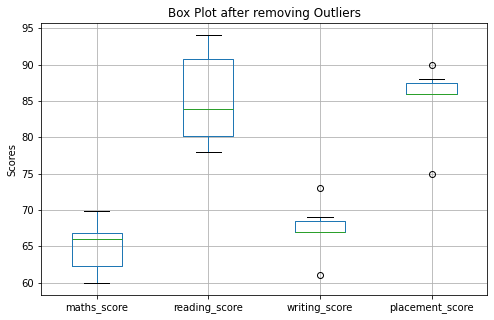

In [28]:
plt.figure(figsize=(8,5))
df[numeric_cols].boxplot()
plt.title("Box Plot after removing Outliers")
plt.ylabel("Scores")
plt.show()

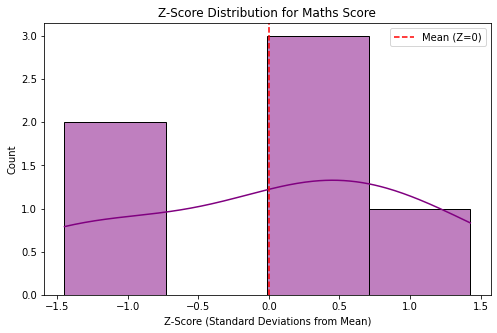

Skewness values:
 maths_score       -0.327052
reading_score      0.459323
writing_score     -0.346543
placement_score   -1.914126
dtype: float64


In [25]:
import seaborn as sns
from scipy import stats

# Calculate Z-scores - returns a numpy array
z_array = stats.zscore(df[numeric_cols])

# Convert back to DataFrame to use column names
z_scores_df = pd.DataFrame(z_array, columns=numeric_cols)

# Plotting the Z-score distribution for 'maths_score'
plt.figure(figsize=(8, 5))
sns.histplot(z_scores_df['maths_score'], kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--', label='Mean (Z=0)')
plt.title("Z-Score Distribution for Maths Score")
plt.xlabel("Z-Score (Standard Deviations from Mean)")
plt.legend()
plt.show()

# Check numerical skewness
print("Skewness values:\n", df[numeric_cols].skew())

In [27]:
df['placement_score_cbrt'] = np.cbrt(df['placement_score'])

# Check Z-scores and Skewness
print("Transformed Skewness:", stats.skew(df['placement_score_cbrt']))

Transformed Skewness: -1.4345968655884276
